In [1]:
from pathlib import Path
import os

DATA_DIR = Path("../Data")

list(DATA_DIR.iterdir())

[WindowsPath('../Data/2015.GRD'),
 WindowsPath('../Data/2016.GRD'),
 WindowsPath('../Data/2017.GRD'),
 WindowsPath('../Data/2018.GRD'),
 WindowsPath('../Data/2019.GRD'),
 WindowsPath('../Data/2020.GRD'),
 WindowsPath('../Data/2021.GRD'),
 WindowsPath('../Data/2022.GRD'),
 WindowsPath('../Data/2023.GRD'),
 WindowsPath('../Data/2024.GRD'),
 WindowsPath('../Data/2025.GRD')]

In [2]:
file_path = DATA_DIR / "2015.GRD"

print(file_path.exists())
print(file_path.stat().st_size)

True
1403060


In [3]:
with open(file_path, "rb") as f:
    raw = f.read(100)

print(raw)
print(len(raw))

b'\xcd\xcc\xc7B\xcd\xcc\xc7B\xcd\xcc\xc7B\xcd\xcc\xc7B\xcd\xcc\xc7B\xcd\xcc\xc7B\xcd\xcc\xc7B\xcd\xcc\xc7B\xcd\xcc\xc7B\xcd\xcc\xc7B\xcd\xcc\xc7B\xcd\xcc\xc7B\xcd\xcc\xc7B\xcd\xcc\xc7B\xcd\xcc\xc7B\xcd\xcc\xc7B\xcd\xcc\xc7B\xcd\xcc\xc7B\xcd\xcc\xc7B\xcd\xcc\xc7B\xcd\xcc\xc7B\xcd\xcc\xc7B\xcd\xcc\xc7B\xcd\xcc\xc7B\xcd\xcc\xc7B'
100


In [4]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.data.grd_parser import (
    read_grd_file,
    get_grid_coordinates,
    grd_to_dataframe
)

In [6]:
import numpy as np 
data_path = PROJECT_ROOT / "Data" / "2015.GRD"

data = read_grd_file(data_path)

print("Shape:", data.shape)
print("Data type:", data.dtype)
print("Minimum:", np.nanmin(data))
print("Maximum:", np.nanmax(data))

Shape: (365, 31, 31)
Data type: float32
Minimum: 4.194188
Maximum: 99.9


In [7]:
latitudes, longitudes = get_grid_coordinates()

print("Latitudes:")
print(latitudes)

print("\nLongitudes:")
print(longitudes)

Latitudes:
[ 7.5  8.5  9.5 10.5 11.5 12.5 13.5 14.5 15.5 16.5 17.5 18.5 19.5 20.5
 21.5 22.5 23.5 24.5 25.5 26.5 27.5 28.5 29.5 30.5 31.5 32.5 33.5 34.5
 35.5 36.5 37.5]

Longitudes:
[67.5 68.5 69.5 70.5 71.5 72.5 73.5 74.5 75.5 76.5 77.5 78.5 79.5 80.5
 81.5 82.5 83.5 84.5 85.5 86.5 87.5 88.5 89.5 90.5 91.5 92.5 93.5 94.5
 95.5 96.5 97.5]


In [8]:
df_2015 = grd_to_dataframe(
    data_path,
    year=2015
)

df_2015.head()

,date,latitude,longitude,max_temperature
0,2015-01-01,7.5,67.5,NaN
1,2015-01-01,7.5,68.5,NaN
2,2015-01-01,7.5,69.5,NaN
3,2015-01-01,7.5,70.5,NaN
4,2015-01-01,7.5,71.5,NaN


In [9]:
df_2015['max_temperature'].value_counts()

max_temperature
31.556541    3
32.282764    3
33.479527    3
33.019817    3
32.834370    3
            ..
13.646674    1
13.602400    1
13.586012    1
13.658913    1
13.677637    1
Name: count, Length: 127994, dtype: int64

In [10]:
df_2015.info()

<class 'pandas.DataFrame'>
RangeIndex: 350765 entries, 0 to 350764
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   date             350765 non-null  datetime64[us]
 1   latitude         350765 non-null  float64       
 2   longitude        350765 non-null  float64       
 3   max_temperature  129360 non-null  float32       
dtypes: datetime64[us](1), float32(1), float64(2)
memory usage: 9.4 MB


In [11]:
df_2015.describe()

,date,latitude,longitude,max_temperature
count,350765,350765.000000,350765.000000,129360.000000
mean,2015-07-01 23:59:59.999999,22.500000,82.500000,30.974447
min,2015-01-01 00:00:00,7.500000,67.500000,4.194188
25%,2015-04-02 00:00:00,14.500000,74.500000,28.349155
50%,2015-07-02 00:00:00,22.500000,82.500000,31.616913
75%,2015-10-01 00:00:00,30.500000,90.500000,34.534691
max,2015-12-31 00:00:00,37.500000,97.500000,46.874161
std,NaN,8.944285,8.944285,5.961623


In [12]:
df_2015.isna().sum()

date                    0
latitude                0
longitude               0
max_temperature    221405
dtype: int64

In [13]:
df_2015["date"].nunique()

365

In [14]:
df_2015[["latitude", "longitude"]].drop_duplicates().shape

(961, 2)

In [15]:
missing_count = df_2015["max_temperature"].isna().sum()
total_count = len(df_2015)

missing_percentage = (missing_count / total_count) * 100

print(f"Missing values: {missing_count:,}")
print(f"Total values: {total_count:,}")
print(f"Missing percentage: {missing_percentage:.2f}%")

Missing values: 221,405
Total values: 350,765
Missing percentage: 63.12%


In [16]:
missing_by_location = (
    df_2015
    .groupby(["latitude", "longitude"])["max_temperature"]
    .apply(lambda x: x.isna().mean() * 100)
    .reset_index(name="missing_percentage")
)

missing_by_location.head()

,latitude,longitude,missing_percentage
0,7.5,67.5,100.0
1,7.5,68.5,100.0
2,7.5,69.5,100.0
3,7.5,70.5,100.0
4,7.5,71.5,100.0


In [17]:
missing_by_location["missing_percentage"].describe()

count    961.000000
mean      63.120608
std       48.213866
min        0.000000
25%        0.000000
50%      100.000000
75%      100.000000
max      100.000000
Name: missing_percentage, dtype: float64

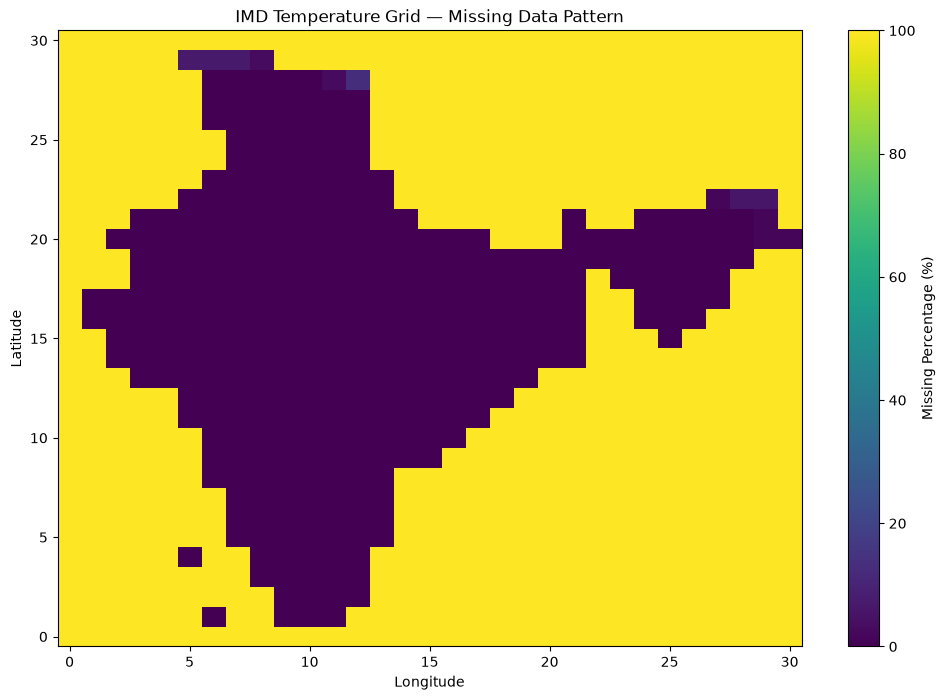

In [18]:
import matplotlib.pyplot as plt

missing_grid = missing_by_location.pivot(
    index="latitude",
    columns="longitude",
    values="missing_percentage"
)

plt.figure(figsize=(12, 8))

plt.imshow(
    missing_grid,
    origin="lower",
    aspect="auto"
)

plt.colorbar(label="Missing Percentage (%)")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("IMD Temperature Grid — Missing Data Pattern")

plt.show()

In [19]:
selected_date = "2015-05-01"

day_data = df_2015[
    df_2015["date"] == selected_date
]

temperature_grid = day_data.pivot(
    index="latitude",
    columns="longitude",
    values="max_temperature"
)

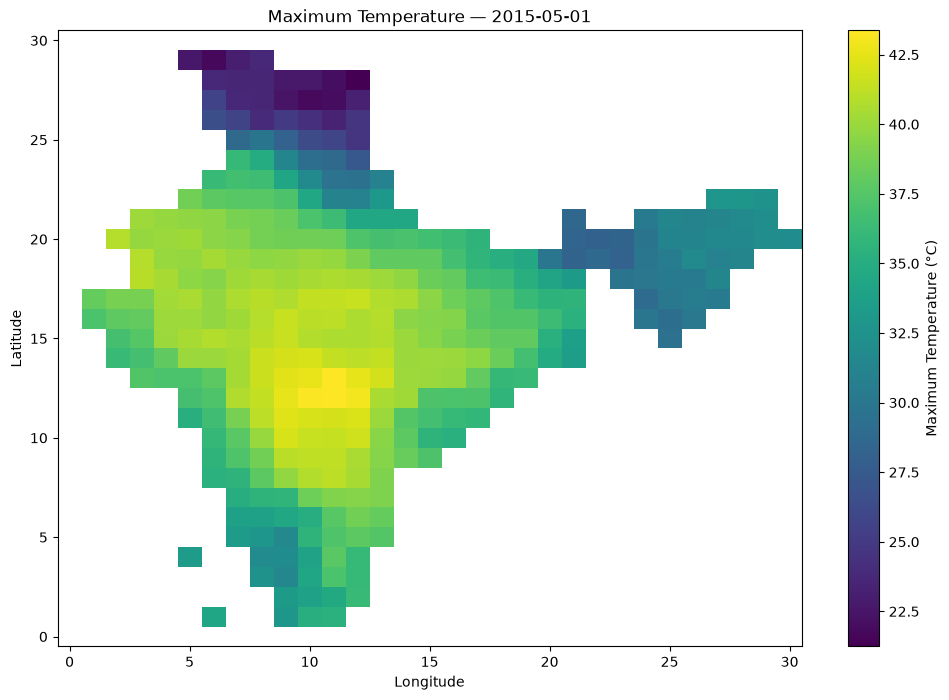

In [20]:
plt.figure(figsize=(12, 8))

plt.imshow(
    temperature_grid,
    origin="lower",
    aspect="auto"
)

plt.colorbar(label="Maximum Temperature (°C)")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Maximum Temperature — {selected_date}")

plt.show()

In [21]:
df_2015.nlargest(
    10,
    "max_temperature"
)[
    ["date", "latitude", "longitude", "max_temperature"]
]
df_2015.nsmallest(
    10,
    "max_temperature"
)[
    ["date", "latitude", "longitude", "max_temperature"]
]

,date,latitude,longitude,max_temperature
32593,2015-02-03,35.5,79.5,4.194188
58565,2015-03-02,36.5,73.5,4.578730
58508,2015-03-02,34.5,78.5,4.813145
58540,2015-03-02,35.5,79.5,4.817851
58507,2015-03-02,34.5,77.5,4.937750
58539,2015-03-02,35.5,78.5,5.179798
32592,2015-02-03,35.5,78.5,5.229824
58506,2015-03-02,34.5,76.5,5.414426
58509,2015-03-02,34.5,79.5,5.454821
58564,2015-03-02,36.5,72.5,5.588445


In [22]:
valid_locations = (
    df_2015
    .groupby(["latitude", "longitude"])["max_temperature"]
    .count()
    .reset_index(name="valid_days")
)

valid_locations.sort_values(
    "valid_days",
    ascending=False
).head(20)

,latitude,longitude,valid_days
878,35.5,77.5,365
877,35.5,76.5,365
849,34.5,79.5,365
848,34.5,78.5,365
847,34.5,77.5,365
846,34.5,76.5,365
845,34.5,75.5,365
844,34.5,74.5,365
818,33.5,79.5,365
817,33.5,78.5,365


In [23]:
valid_locations.sort_values(
    "valid_days"
).head(20)

,latitude,longitude,valid_days
957,37.5,94.5,0
930,37.5,67.5,0
929,36.5,97.5,0
48,8.5,84.5,0
47,8.5,83.5,0
46,8.5,82.5,0
45,8.5,81.5,0
44,8.5,80.5,0
43,8.5,79.5,0
39,8.5,75.5,0


In [24]:
# Calculate number of valid observations at each grid location

location_stats = (
    df_2015
    .groupby(["latitude", "longitude"])["max_temperature"]
    .agg(
        valid_days="count",
        missing_days=lambda x: x.isna().sum()
    )
    .reset_index()
)

location_stats.head()

,latitude,longitude,valid_days,missing_days
0,7.5,67.5,0,365
1,7.5,68.5,0,365
2,7.5,69.5,0,365
3,7.5,70.5,0,365
4,7.5,71.5,0,365


In [26]:
valid_locations = location_stats[
    location_stats["valid_days"] > 0
][["latitude", "longitude"]].copy()

print("Total grid points:", len(location_stats))
print("Valid grid points:", len(valid_locations))
print("Invalid grid points:", len(location_stats) - len(valid_locations))

Total grid points: 961
Valid grid points: 355
Invalid grid points: 606


In [27]:
usable_2015 = df_2015.merge(
    valid_locations,
    on=["latitude", "longitude"],
    how="inner"
)

print("Original rows:", len(df_2015))
print("Usable rows:", len(usable_2015))
print(
    "Remaining missing temperatures:",
    usable_2015["max_temperature"].isna().sum()
)

Original rows: 350765
Usable rows: 129575
Remaining missing temperatures: 215


In [29]:
import pandas as pd

In [30]:
years = range(2015, 2026)

file_stats = []

for year in years:
    file_path = DATA_DIR / f"{year}.GRD"

    data = read_grd_file(file_path)

    file_stats.append({
        "year": year,
        "file_size_mb": file_path.stat().st_size / (1024 ** 2),
        "days": data.shape[0],
        "grid_rows": data.shape[1],
        "grid_cols": data.shape[2],
        "dtype": str(data.dtype)
    })

file_stats_df = pd.DataFrame(file_stats)

file_stats_df

,year,file_size_mb,days,grid_rows,grid_cols,dtype
0,2015,1.338062,365,31,31,float32
1,2016,1.341728,366,31,31,float32
2,2017,1.338062,365,31,31,float32
3,2018,1.338062,365,31,31,float32
4,2019,1.338062,365,31,31,float32
5,2020,1.341728,366,31,31,float32
6,2021,1.338062,365,31,31,float32
7,2022,1.338062,365,31,31,float32
8,2023,1.338062,365,31,31,float32
9,2024,1.341728,366,31,31,float32
